# Meteorological Indicators, Exposure, and EF Rating in U.S. Tornadoes, 2010–2025

## 1. Study Overview

This study examines how radar indicators, tornado characteristics, and land-cover
exposure proxies relate to recorded EF ratings for U.S. tornadoes from 2010–2025.
It extends the previous classification study using retrospective and onset data
views and controlled neural-network experiments.

- **Primary research:** How do meteorology, tornado characteristics, and exposure
  relate to final EF rating?
- **Secondary experiment:** How well can final EF rating be estimated using
  features eligible by reported onset?
- **Modeling methodology:** How do learning rate, SGD, L2 regularization, and
  dropout affect training, generalization, and overfitting?

EF is a damage-based rating, not a direct wind measurement.

## 2. Setup

### Imports and seeds

In [1]:
import hashlib
import json
import os
import platform
import random
import textwrap
from importlib.metadata import version
from pathlib import Path

# Locate the project when Jupyter starts in a subdirectory.
PROJECT_ROOT = next(
    (p for p in (Path.cwd(), *Path.cwd().parents)
     if (p / 'pyproject.toml').is_file() and (p / 'notebook.ipynb').is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError('Launch this notebook from within the project directory.')

os.environ.setdefault('MPLCONFIGDIR', str(PROJECT_ROOT / 'data/.cache/matplotlib'))

import joblib
import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

# Reset these seeds and the TensorFlow seed before each later training run.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

environment = pd.DataFrame({
    'Package': ['Python', 'kagglehub', 'numpy', 'pandas', 'pyarrow', 'matplotlib', 'scikit-learn', 'joblib'],
    'Version': [platform.python_version()] + [
        version(package) for package in
        ['kagglehub', 'numpy', 'pandas', 'pyarrow', 'matplotlib', 'scikit-learn', 'joblib']
    ],
})
display(environment)

,Package,Version
0,Python,3.12.12
1,kagglehub,1.0.2
2,numpy,2.5.3
3,pandas,3.0.5
4,pyarrow,25.0.1
5,matplotlib,3.11.2
6,scikit-learn,1.9.1
7,joblib,1.6.0


### Configuration

In [2]:
DATASET = 'jakevanslyke/us-tornado-data-2010-2025/versions/8'
RELEASE = 'v2.2.1'
MANIFEST_SHA256 = '9a4ec9b89cbf43cdfa88db26360881aab84437fee619f1b98e1fb04a338f8feb'
DATA_DIR = PROJECT_ROOT / 'data'
SOURCE_DIR = DATA_DIR / 'source/v8'
DERIVED_DIR = DATA_DIR / 'derived'
RESULTS_DIR = DATA_DIR / 'results'
AUDIT_DIR = RESULTS_DIR / 'audit'
FIGURE_DIR = PROJECT_ROOT / 'assets/figures'
TABLE_DIR = PROJECT_ROOT / 'assets/tables'

for directory in (SOURCE_DIR, DERIVED_DIR, AUDIT_DIR, FIGURE_DIR, TABLE_DIR):
    directory.mkdir(parents=True, exist_ok=True)

ML_FILES = (
    'ml/events_onset.parquet',
    'ml/events_retrospective.parquet',
    'ml/feature_dictionary.json',
)

EXPERIMENT_SETTINGS = {
    'seed': SEED,
    'sgd_learning_rates': [0.1, 0.01, 0.001],
    'l2_starting_strength': 0.001,
    'dropout_rates': [0.0, 0.2, 0.5],
}
print(f'Dataset: {DATASET}')
print(f'Local source files: {SOURCE_DIR.relative_to(PROJECT_ROOT)}')

Dataset: jakevanslyke/us-tornado-data-2010-2025/versions/8
Local source files: data/source/v8


### Plot and table style

In [3]:
EF_ORDER = ['EF0', 'EF1', 'EF2', 'EF3', 'EF4', 'EF5', 'Unknown']
EF_COLORS = dict(zip(EF_ORDER, [
    '#0072B2', '#56B4E9', '#009E73', '#E69F00', '#D55E00', '#CC79A7', '#999999'
]))
ACCENT = '#0072B2'

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.axisbelow': True,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.facecolor': 'white',
    'figure.dpi': 110,
    'savefig.dpi': 300,
    'svg.fonttype': 'none',
})
pd.set_option('display.max_columns', 12)
pd.set_option('display.precision', 3)

### Saving helpers

In [4]:
def save_json(value, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(value, indent=2, allow_nan=False) + '\n')


def save_figure(fig, name, directory=FIGURE_DIR):
    for extension in ('png', 'svg'):
        fig.savefig(directory / f'{name}.{extension}', bbox_inches='tight')


def save_table(frame, name, title, *, caption, formats=None, note=None,
               width=9, results_dir=AUDIT_DIR):
    """Save numeric CSV plus a legible, consistently styled table image."""
    results_dir = Path(results_dir)
    results_dir.mkdir(parents=True, exist_ok=True)
    frame.to_csv(results_dir / f'{name}.csv', index=False)
    shown = frame.copy()
    for column, pattern in (formats or {}).items():
        shown[column] = shown[column].map(
            lambda value: '—' if pd.isna(value) else format(value, pattern)
        )
    shown = shown.fillna('—').astype(str)
    note_lines = textwrap.wrap(note, width=110) if note else []
    height = 0.34 * (len(frame) + 1.5) + 0.65 + 0.18 * len(note_lines)
    fig, ax = plt.subplots(figsize=(width, height))
    ax.axis('off')
    fig.text(0.03, 1 - 0.22 / height, title, fontsize=12, weight='bold', va='top')
    headers = [textwrap.fill(str(c), width=22) for c in frame.columns]
    column_widths = np.array([
        max(max(map(len, header.splitlines())), shown[column].str.len().max()) + 3
        for column, header in zip(frame.columns, headers)
    ], dtype=float)
    table = ax.table(
        cellText=shown.values,
        colLabels=headers, colWidths=column_widths / column_widths.sum(),
        cellLoc='right', colLoc='left', bbox=[0, 0, 1, 1],
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    for (row, col), cell in table.get_celld().items():
        cell.set_edgecolor('#D6DEE5')
        cell.set_linewidth(0.5)
        if row == 0:
            cell.set_facecolor('#E7EEF4')
            cell.set_text_props(weight='bold', color='#172B3A')
            cell.set_height(cell.get_height() * 1.5)
        else:
            cell.set_facecolor('#F6F8FA' if row % 2 == 0 else 'white')
        if col == 0:
            cell.set_text_props(ha='left')
    if note_lines:
        fig.text(0.03, 0.03, '\n'.join(note_lines), fontsize=9, color='#46535F')
    fig.subplots_adjust(
        left=0.03, right=0.97, top=1 - 0.55 / height,
        bottom=(0.16 + 0.22 * len(note_lines)) / height,
    )
    save_figure(fig, name, TABLE_DIR)
    plt.show()
    display(Markdown(caption))
    plt.close(fig)


def file_sha256(path):
    with Path(path).open('rb') as stream:
        return hashlib.file_digest(stream, 'sha256').hexdigest()

## 3. Data

[US Tornado Data, 2010–2025](https://www.kaggle.com/datasets/jakevanslyke/us-tornado-data-2010-2025/versions/8)
provides matching retrospective and onset tables. Check their consistency and
summarize class balance, annual coverage, and missingness, retaining unknown
ratings in these summaries.

Exposure initially means retrospective land-cover measures. Missing radar maxima
can reflect no qualifying detection; missing warning lead time can reflect no
active warning. Completed collection jobs do not guarantee usable observations.

### Download

In [5]:
def ensure_source_file(relative_path, expected_sha256):
    destination = SOURCE_DIR / relative_path
    # Reuse local files; output_dir bypasses the global Kaggle cache.
    if not destination.is_file():
        kagglehub.dataset_download(
            DATASET, path=relative_path, output_dir=str(SOURCE_DIR)
        )
    actual = file_sha256(destination)
    if actual != expected_sha256:
        raise ValueError(
            f'Checksum mismatch for {relative_path}. Inspect the local file and '
            'release before removing it and rerunning the download cell.'
        )
    return destination


manifest_path = ensure_source_file('release_manifest.json', MANIFEST_SHA256)
manifest = json.loads(manifest_path.read_text())
assert manifest['version'] == RELEASE
release_files = {entry['path']: entry for entry in manifest['files']}

verified_files = []
for relative_path in ML_FILES:
    entry = release_files[relative_path]
    path = ensure_source_file(relative_path, entry['sha256'])
    assert path.stat().st_size == entry['bytes'], relative_path
    verified_files.append({
        'path': relative_path, 'bytes': path.stat().st_size,
        'sha256': entry['sha256'],
    })

save_json({
    'dataset_handle': DATASET,
    'dataset_url': f'https://www.kaggle.com/datasets/{DATASET}',
    'release': RELEASE,
    'source_code_commit': manifest['code_commit'],
    'release_manifest_sha256': MANIFEST_SHA256,
    'files': verified_files,
}, SOURCE_DIR / 'provenance.json')
print(f'Verified {len(verified_files)} modeling files against {RELEASE}.')
print('All dataset files are stored under data/source/v8/.')

Verified 3 modeling files against v2.2.1.
All dataset files are stored under data/source/v8/.


### Load data

In [6]:
onset = pd.read_parquet(SOURCE_DIR / 'ml/events_onset.parquet')
retrospective = pd.read_parquet(SOURCE_DIR / 'ml/events_retrospective.parquet')
spec = json.loads((SOURCE_DIR / 'ml/feature_dictionary.json').read_text())

ID, TARGET, GROUP = spec['id'], spec['target'], spec['group']
tables = {'Onset': onset, 'Retrospective': retrospective}
# Use the dictionary allowlists; numeric metadata is not a predictor.
predictors = {
    'Onset': spec['onset_predictor_columns'],
    'Retrospective': spec['retrospective_predictor_columns'],
}
inventory = pd.DataFrame([
    {'View': view, 'Events': len(frame), 'Columns': len(frame.columns),
     'Default predictors': len(predictors[view])}
    for view, frame in tables.items()
])
display(inventory)

feature_roles = pd.DataFrame([
    {'column': column, 'role': details['role'],
     'onset_predictor': column in predictors['Onset'],
     'retrospective_predictor': column in predictors['Retrospective'],
     'units': details.get('units'), 'window': details.get('window')}
    for column, details in spec['columns'].items()
])
feature_roles.to_csv(AUDIT_DIR / 'feature_roles.csv', index=False)
display(feature_roles[['column', 'role', 'onset_predictor', 'retrospective_predictor']])

,View,Events,Columns,Default predictors
0,Onset,20164,30,15
1,Retrospective,20164,53,32


,column,role,onset_predictor,retrospective_predictor
0,tornado_id,metadata,False,False
1,target_ef_rating,target,False,False
2,target_known,metadata,False,False
3,onset_utc,metadata,False,False
4,prediction_cutoff_utc,metadata,False,False
5,start_longitude,onset_predictor_candidate,True,True
6,start_latitude,onset_predictor_candidate,True,True
7,year,metadata,False,False
8,month,onset_predictor_candidate,True,True
9,hour_utc,onset_predictor_candidate,True,True


### Validation

In [7]:
assert spec['schema_version'] == 2
expected_rows = manifest['source_verification']['counts']['spc_tracks']
for view, frame in tables.items():
    assert len(frame) == expected_rows, view
    assert frame[ID].notna().all() and frame[ID].is_unique, view
    assert frame[GROUP].notna().all(), view
    assert frame['target_known'].notna().all(), view
    assert frame['target_known'].eq(frame[TARGET].notna()).all(), view
    assert frame[TARGET].dropna().isin(range(6)).all(), view
    assert frame['year'].between(manifest['start_year'], manifest['end_year']).all()
    assert frame['onset_utc'].notna().all(), view
    assert frame['prediction_cutoff_utc'].eq(frame['onset_utc']).all(), view
    columns = predictors[view]
    assert len(columns) == len(set(columns)), view
    assert set(columns).issubset(frame.columns), view
    assert all(spec['columns'][c]['role'] in {
        'onset_predictor_candidate', 'retrospective_candidate'
    } for c in columns), view
    numeric = frame[columns].select_dtypes(include='number')
    assert not np.isinf(numeric.to_numpy(dtype=float, na_value=np.nan)).any(), view

assert set(predictors['Onset']).issubset(predictors['Retrospective'])
assert not any(c.startswith('post_') for c in predictors['Onset'])
assert all(spec['columns'][c]['eligible_for_conditional_onset']
           for c in predictors['Onset'])
assert all(spec['columns'][c]['available_by_onset'] is None
           for c in predictors['Onset'])
pd.testing.assert_frame_equal(
    onset.set_index(ID).sort_index(),
    retrospective.set_index(ID).sort_index()[onset.columns.drop(ID)],
)

validation = {
    'release': RELEASE, 'events_per_view': expected_rows,
    'unique_ids': True, 'shared_columns_identical': True,
    'target_and_predictor_roles_valid': True,
    'onset_availability': spec['availability_contract'],
}
save_json(validation, AUDIT_DIR / 'validation.json')
print('Passed: file hashes, event IDs, shared columns, labels, and feature roles.')

Passed: file hashes, event IDs, shared columns, labels, and feature roles.


### Data summary

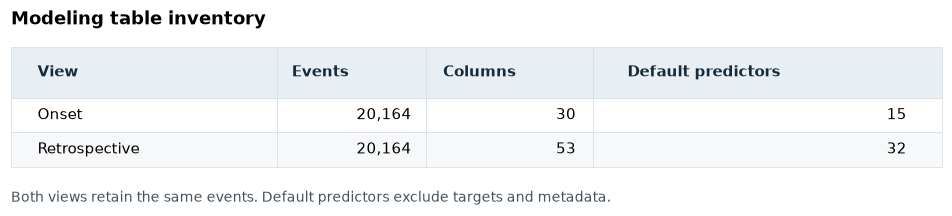

**Table 1.** Event and predictor counts for the two modeling views.

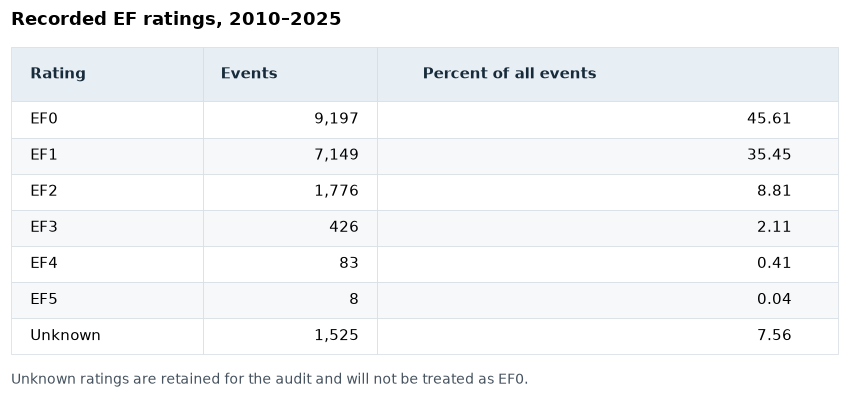

**Table 2.** Counts and percentages of recorded EF ratings, including unknown ratings.

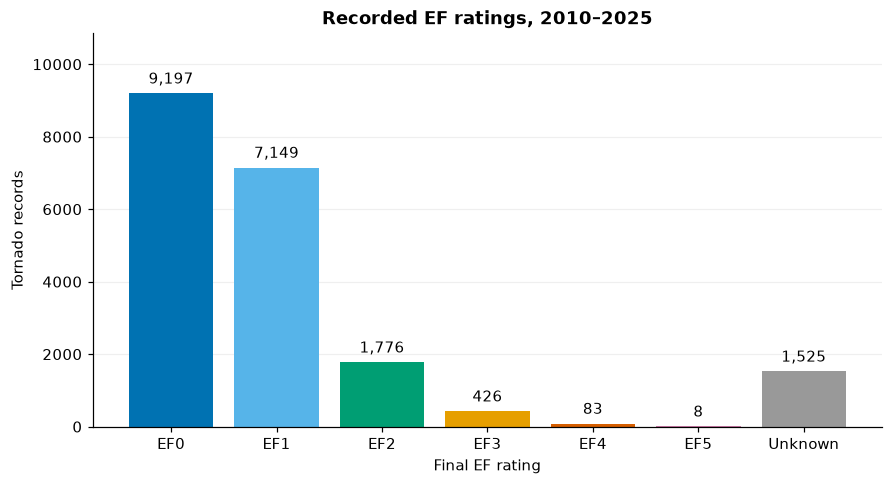

**Figure 1.** Distribution of recorded EF ratings, 2010–2025.

In [8]:
save_table(
    inventory, 'table_01_dataset_inventory', 'Modeling table inventory',
    caption='**Table 1.** Event and predictor counts for the two modeling views.',
    formats={'Events': ',d', 'Columns': 'd', 'Default predictors': 'd'},
    note='Both views retain the same events. Default predictors exclude targets and metadata.',
)

rating_labels = onset[TARGET].map({i: f'EF{i}' for i in range(6)}).fillna('Unknown')
class_counts = rating_labels.value_counts().reindex(EF_ORDER, fill_value=0)
class_balance = pd.DataFrame({
    'Rating': class_counts.index,
    'Events': class_counts.values,
    'Percent of all events': 100 * class_counts.values / len(onset),
})
save_table(
    class_balance, 'table_02_class_balance', 'Recorded EF ratings, 2010–2025',
    caption='**Table 2.** Counts and percentages of recorded EF ratings, including unknown ratings.',
    formats={'Events': ',d', 'Percent of all events': '.2f'},
    note='Unknown ratings are retained for the audit and will not be treated as EF0.',
    width=8,
)

fig, ax = plt.subplots(figsize=(8, 4.3), layout='constrained')
bars = ax.bar(EF_ORDER, class_counts, color=[EF_COLORS[c] for c in EF_ORDER])
ax.bar_label(bars, labels=[f'{n:,}' for n in class_counts], padding=4, fontsize=10)
ax.set(title='Recorded EF ratings, 2010–2025', ylabel='Tornado records', xlabel='Final EF rating')
ax.set_ylim(0, class_counts.max() * 1.18)
ax.grid(axis='y', alpha=0.2)
save_figure(fig, 'fig_01_class_distribution')
plt.show()
display(Markdown('**Figure 1.** Distribution of recorded EF ratings, 2010–2025.'))
plt.close(fig)

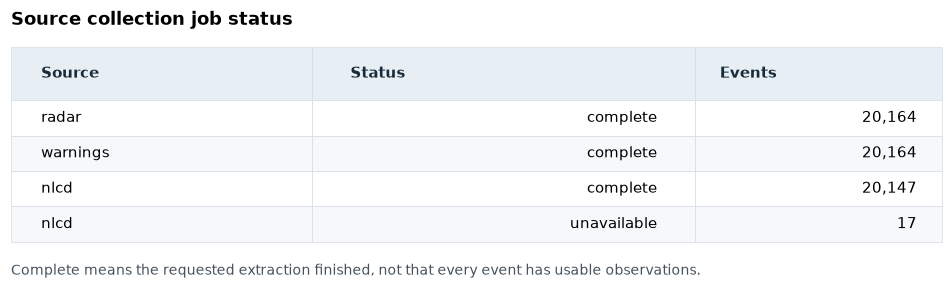

**Table 3.** Collection job status for radar, warnings, and land cover.

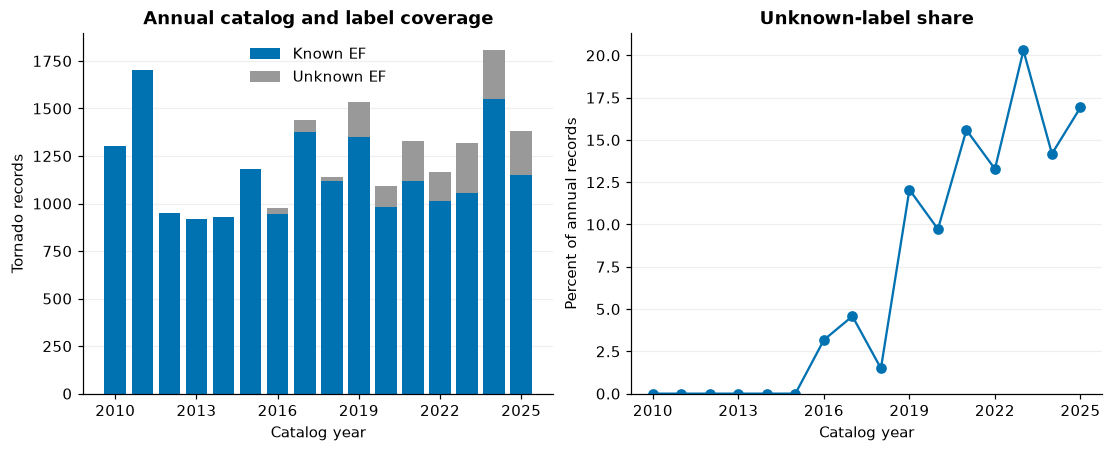

**Figure 2.** Annual known and unknown EF counts and the unknown-label share.

In [9]:
annual = onset.groupby('year').agg(
    events=(ID, 'size'), known_labels=('target_known', 'sum')
)
annual['unknown_labels'] = annual['events'] - annual['known_labels']
annual['unknown_percent'] = 100 * annual['unknown_labels'] / annual['events']
annual.reset_index().to_csv(AUDIT_DIR / 'annual_label_coverage.csv', index=False)

source_coverage = pd.concat([
    onset[f'{source}_source_status'].value_counts(dropna=False)
    .rename_axis('Status').reset_index(name='Events').assign(Source=source)
    for source in ('radar', 'warnings', 'nlcd')
], ignore_index=True)[['Source', 'Status', 'Events']]
save_table(
    source_coverage, 'table_03_source_job_status', 'Source collection job status',
    caption='**Table 3.** Collection job status for radar, warnings, and land cover.',
    formats={'Events': ',d'},
    note='Complete means the requested extraction finished, not that every event has usable observations.',
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), layout='constrained')
axes[0].bar(annual.index, annual['known_labels'], label='Known EF', color=ACCENT)
axes[0].bar(annual.index, annual['unknown_labels'], bottom=annual['known_labels'],
            label='Unknown EF', color=EF_COLORS['Unknown'])
axes[0].set(title='Annual catalog and label coverage', ylabel='Tornado records')
axes[0].legend(frameon=False)
axes[1].plot(annual.index, annual['unknown_percent'], marker='o', color=ACCENT)
axes[1].set(title='Unknown-label share', ylabel='Percent of annual records', ylim=(0, None))
for ax in axes:
    ax.set_xlabel('Catalog year')
    ax.set_xticks(annual.index[::3])
    ax.grid(axis='y', alpha=0.2)
save_figure(fig, 'fig_02_annual_label_coverage')
plt.show()
display(Markdown('**Figure 2.** Annual known and unknown EF counts and the unknown-label share.'))
plt.close(fig)

,view,feature,missing_events,total_events,missing_percent
7,Onset,radar_max_shear_per_s,13260,20164,65.761
8,Onset,radar_max_velocity_difference_knots,13260,20164,65.761
22,Retrospective,radar_max_shear_per_s,13260,20164,65.761
23,Retrospective,radar_max_velocity_difference_knots,13260,20164,65.761
39,Retrospective,post_radar_max_velocity_difference_knots,10564,20164,52.390
38,Retrospective,post_radar_max_shear_per_s,10564,20164,52.390
14,Onset,warning_tornado_lead_minutes,8819,20164,43.736
29,Retrospective,warning_tornado_lead_minutes,8819,20164,43.736
9,Onset,radar_max_rotation_velocity_knots,5236,20164,25.967
24,Retrospective,radar_max_rotation_velocity_knots,5236,20164,25.967


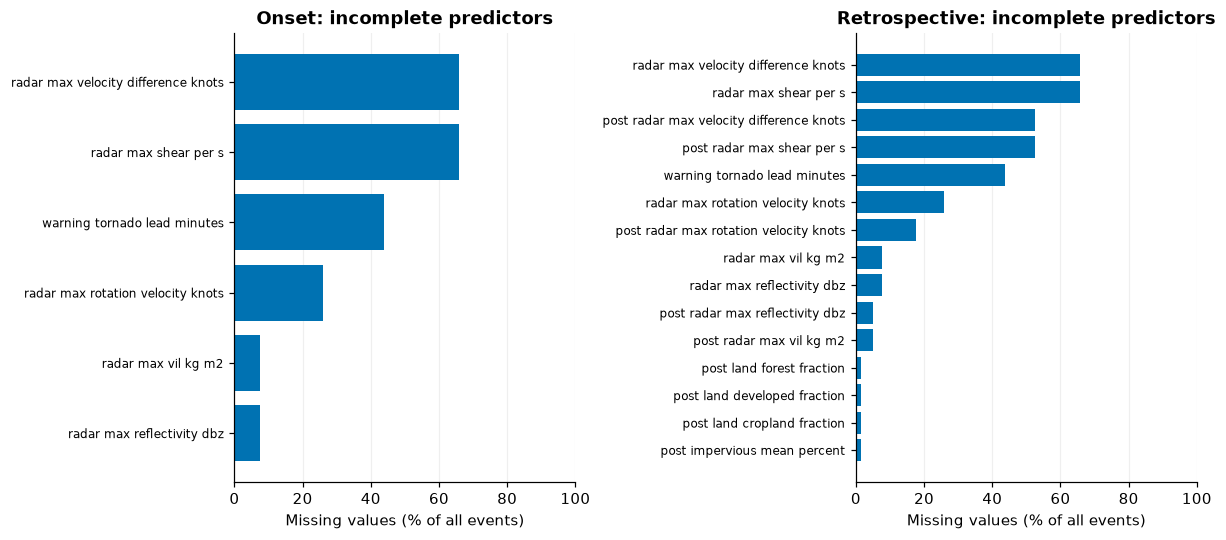

**Figure 3.** Missing-value percentages for incomplete predictors in each modeling view.

2,255 split groups; largest group: 400 events.
Audit complete. No events dropped; no splits, preprocessing, or models fitted.


In [10]:
missingness_rows = []
for view, frame in tables.items():
    missing = frame[predictors[view]].isna().sum()
    missingness_rows.extend(
        {'view': view, 'feature': column, 'missing_events': int(count),
         'total_events': len(frame), 'missing_percent': 100 * count / len(frame)}
        for column, count in missing.items()
    )

missingness = pd.DataFrame(missingness_rows)
missingness.to_csv(AUDIT_DIR / 'feature_missingness.csv', index=False)
display(missingness.sort_values('missing_percent', ascending=False).head(12))

for view, frame in tables.items():
    flags = frame[predictors[view]].isna()
    for stratum, labels in [('year', frame['year']), ('rating', rating_labels)]:
        grouped = flags.groupby(labels.rename(stratum))
        counts = grouped.sum().rename_axis(columns='feature').stack().rename('missing_events')
        summary = counts.reset_index()
        summary['total_events'] = summary[stratum].map(grouped.size())
        summary['missing_percent'] = 100 * summary['missing_events'] / summary['total_events']
        summary.to_csv(AUDIT_DIR / f'{view.lower()}_missingness_by_{stratum}.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.8), layout='constrained')
for ax, view in zip(axes, tables):
    selected = missingness.loc[
        (missingness['view'] == view) & (missingness['missing_events'] > 0)
    ].sort_values('missing_percent')
    labels = selected['feature'].str.replace('_', ' ')
    ax.barh(labels, selected['missing_percent'], color=ACCENT)
    ax.set(title=f'{view}: incomplete predictors', xlabel='Missing values (% of all events)', xlim=(0, 100))
    ax.tick_params(axis='y', labelsize=8)
    ax.grid(axis='x', alpha=0.2)
save_figure(fig, 'fig_03_feature_missingness')
plt.show()
display(Markdown('**Figure 3.** Missing-value percentages for incomplete predictors in each modeling view.'))
plt.close(fig)

group_sizes = onset.groupby(GROUP).size().rename('events')
group_sizes.to_csv(AUDIT_DIR / 'split_group_sizes.csv')
save_json({
    'release': RELEASE,
    'events': len(onset),
    'known_labels': int(onset['target_known'].sum()),
    'unknown_labels': int((~onset['target_known']).sum()),
    'class_counts': {label: int(count) for label, count in class_counts.items()},
    'split_groups': int(len(group_sizes)),
    'largest_split_group': int(group_sizes.max()),
    'seed': SEED,
    'environment': dict(zip(environment['Package'], environment['Version'])),
}, AUDIT_DIR / 'summary.json')
print(f'{len(group_sizes):,} split groups; largest group: {group_sizes.max():,} events.')
print('Audit complete. No events dropped; no splits, preprocessing, or models fitted.')

## 4. Analysis Preparation

Use **2010–2019 for training**, **2020–2022 for validation**, and **2023–2025
for testing**, with shared event assignments for both tasks. Exclude unknown
labels and any source-linkage groups crossing these calendar boundaries.

Training-data exploration guides transformations. Training and validation class
support determine the starting target; model performance is not assessed here.
Fit preprocessing and class weights on training data only. Reserve test evaluation
for the final selected models.

### Cohort and splits

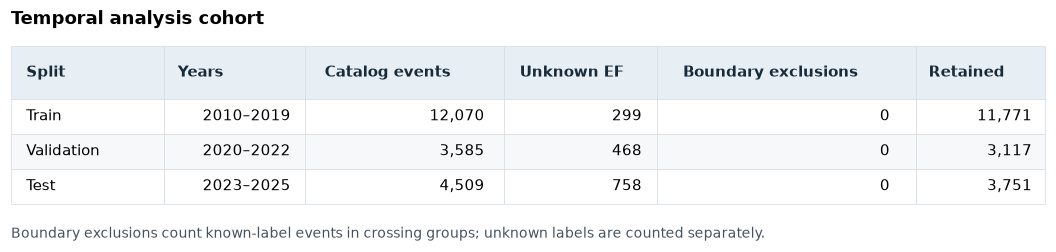

**Table 4.** Shared event splits after excluding unknown labels and crossing groups.

In [11]:
PREPARATION_DIR = RESULTS_DIR / 'preparation'
PREPARATION_DIR.mkdir(parents=True, exist_ok=True)
SPLIT_ORDER = ['train', 'validation', 'test']
TRAIN_END = pd.Timestamp('2020-01-01', tz='UTC')
VALIDATION_END = pd.Timestamp('2023-01-01', tz='UTC')

assignments = onset[[ID, GROUP, 'onset_utc', 'target_known']].copy()
assignments['period'] = np.select(
    [assignments['onset_utc'] < TRAIN_END,
     assignments['onset_utc'] < VALIDATION_END],
    ['train', 'validation'], default='test',
)
# Inspect all records before excluding unknown labels, preserving linkage groups.
crossing = assignments.groupby(GROUP)['period'].nunique().gt(1)
assignments['crosses_boundary'] = assignments[GROUP].map(crossing)
assignments['eligible'] = assignments['target_known'] & ~assignments['crosses_boundary']
assignments['split'] = assignments['period'].where(assignments['eligible'], 'excluded')
assignments['exclusion_reason'] = np.select(
    [~assignments['target_known'] & assignments['crosses_boundary'],
     ~assignments['target_known'], assignments['crosses_boundary']],
    ['unknown_label;crossing_group', 'unknown_label', 'crossing_group'], default='',
)
assignments.to_parquet(DERIVED_DIR / 'split_assignments.parquet', index=False)

split_ids = {
    split: assignments.loc[assignments['split'].eq(split), ID].tolist()
    for split in SPLIT_ORDER
}
split_groups = {
    split: set(assignments.loc[assignments['split'].eq(split), GROUP])
    for split in SPLIT_ORDER
}
for i, first in enumerate(SPLIT_ORDER):
    assert split_ids[first], f'Empty {first} split'
    for second in SPLIT_ORDER[i + 1:]:
        assert set(split_ids[first]).isdisjoint(split_ids[second])
        assert split_groups[first].isdisjoint(split_groups[second])

indexed_tables = {view: frame.set_index(ID) for view, frame in tables.items()}
cohorts = {
    view: {split: frame.loc[split_ids[split]].copy() for split in SPLIT_ORDER}
    for view, frame in indexed_tables.items()
}
for split in SPLIT_ORDER:
    pd.testing.assert_series_equal(
        cohorts['Onset'][split][TARGET], cohorts['Retrospective'][split][TARGET]
    )
assert cohorts['Onset']['train']['onset_utc'].max() < TRAIN_END
assert cohorts['Onset']['validation']['onset_utc'].between(
    TRAIN_END, VALIDATION_END, inclusive='left'
).all()
assert cohorts['Onset']['test']['onset_utc'].min() >= VALIDATION_END

split_summary = pd.DataFrame([
    {'Split': split.title(), 'Years': years,
     'Catalog events': int(assignments['period'].eq(split).sum()),
     'Unknown EF': int((assignments['period'].eq(split) & ~assignments['target_known']).sum()),
     'Boundary exclusions': int((assignments['period'].eq(split) &
                                 assignments['target_known'] & assignments['crosses_boundary']).sum()),
     'Retained': len(split_ids[split])}
    for split, years in zip(SPLIT_ORDER, ['2010–2019', '2020–2022', '2023–2025'])
])
save_table(
    split_summary, 'table_04_cohort_splits', 'Temporal analysis cohort',
    caption='**Table 4.** Shared event splits after excluding unknown labels and crossing groups.',
    formats={c: ',d' for c in split_summary.columns[2:]}, width=10,
    note='Boundary exclusions count known-label events in crossing groups; unknown labels are counted separately.',
    results_dir=PREPARATION_DIR,
)
save_json({
    'time_basis': 'reported onset in UTC',
    'train_end_exclusive': TRAIN_END.isoformat(),
    'validation_end_exclusive': VALIDATION_END.isoformat(),
    'crossing_groups': int(crossing.sum()),
    'unknown_labels_excluded': int((~assignments['target_known']).sum()),
    'retained_events': {s: len(ids) for s, ids in split_ids.items()},
}, PREPARATION_DIR / 'split_summary.json')

### Training-data exploration

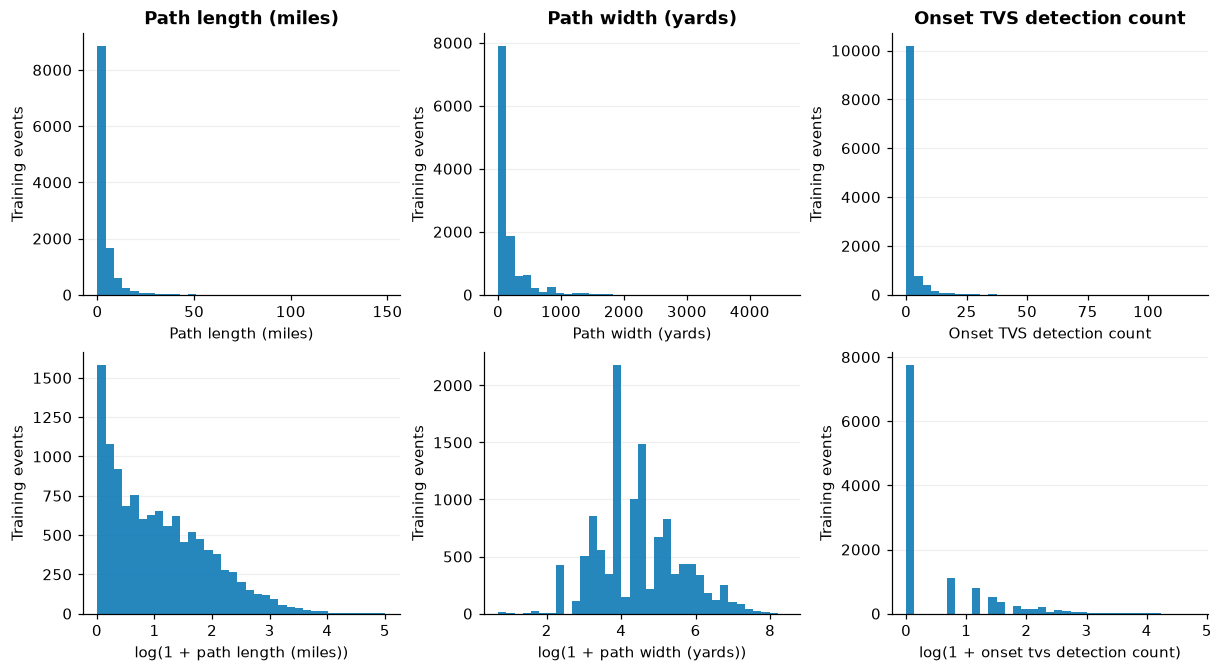

**Figure 4.** Training distributions before and after log(1 + x), illustrating long right tails.

In [12]:
train = cohorts['Retrospective']['train']
train_numeric = train[predictors['Retrospective']].select_dtypes(include='number')
training_profile = train_numeric.describe().T
training_profile['missing_percent'] = train_numeric.isna().mean() * 100
training_profile['skew'] = train_numeric.skew()
training_profile['spearman_with_ef'] = train_numeric.corrwith(
    train[TARGET].astype(float), method='spearman'
)
training_profile.to_csv(PREPARATION_DIR / 'training_feature_profile.csv', index_label='feature')

distribution_features = {
    'post_path_length_miles': 'Path length (miles)',
    'post_path_width_yards': 'Path width (yards)',
    'radar_tvs_count': 'Onset TVS detection count',
}
fig, axes = plt.subplots(2, 3, figsize=(11, 6), layout='constrained')
for column, (feature, label) in enumerate(distribution_features.items()):
    values = train[feature].dropna().astype(float)
    for row, (shown, xlabel) in enumerate([
        (values, label), (np.log1p(values), f'log(1 + {label.lower()})')
    ]):
        ax = axes[row, column]
        ax.hist(shown, bins=35, color=ACCENT, alpha=0.85)
        ax.set(xlabel=xlabel, ylabel='Training events')
        ax.grid(axis='y', alpha=0.2)
        if row == 0:
            ax.set_title(label)
save_figure(fig, 'fig_04_training_distributions')
plt.show()
display(Markdown('**Figure 4.** Training distributions before and after log(1 + x), illustrating long right tails.'))
plt.close(fig)

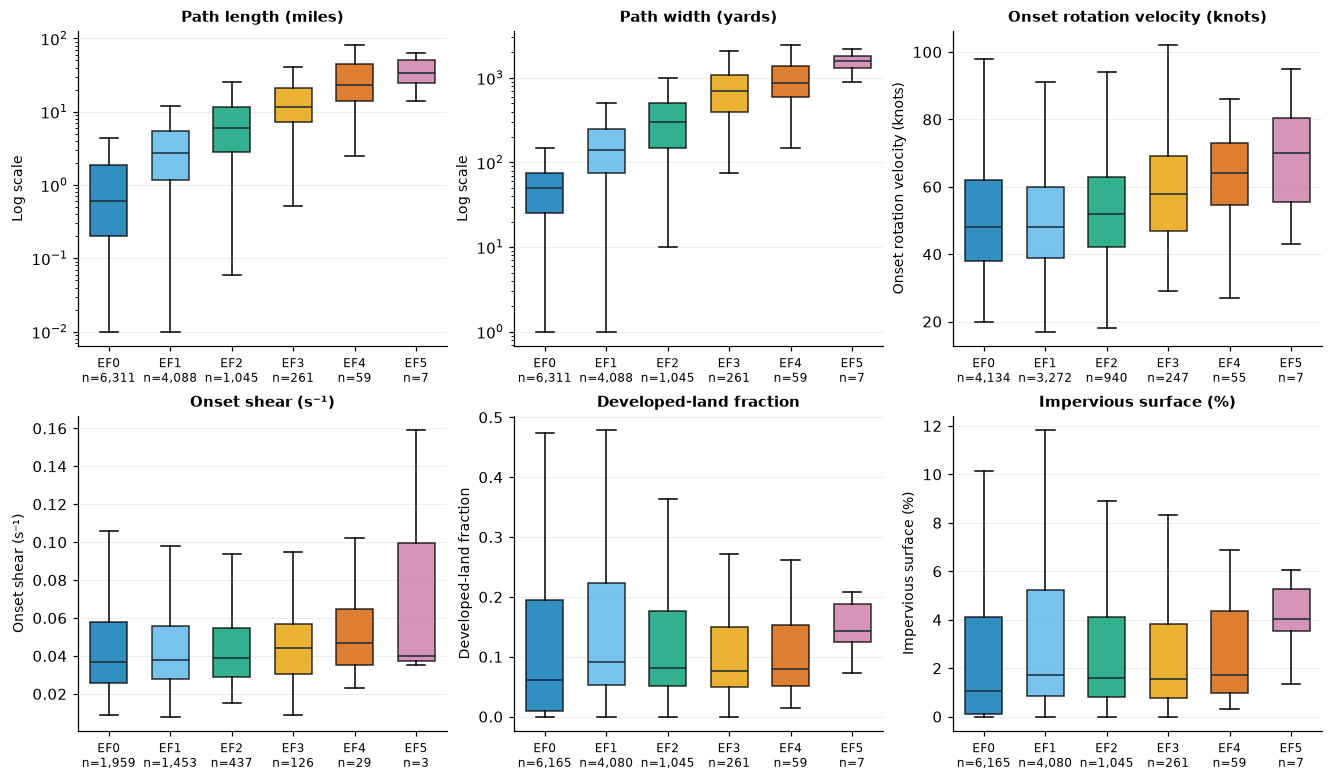

**Figure 5.** Training predictors by original EF rating. Boxes show medians and interquartile ranges; whiskers extend to 1.5 times the IQR and outliers are hidden. Each n counts observed values for that feature; rare-class and missing-data patterns limit interpretation.

In [13]:
relationship_features = [
    ('post_path_length_miles', 'Path length (miles)', True),
    ('post_path_width_yards', 'Path width (yards)', True),
    ('radar_max_rotation_velocity_knots', 'Onset rotation velocity (knots)', False),
    ('radar_max_shear_per_s', 'Onset shear (s⁻¹)', False),
    ('post_land_developed_fraction', 'Developed-land fraction', False),
    ('post_impervious_mean_percent', 'Impervious surface (%)', False),
]
fig, axes = plt.subplots(2, 3, figsize=(12, 7), layout='constrained')
for ax, (feature, label, log_axis) in zip(axes.flat, relationship_features):
    values = [train.loc[train[TARGET].eq(ef), feature].dropna().to_numpy(dtype=float)
              for ef in range(6)]
    boxes = ax.boxplot(values, tick_labels=[f'EF{ef}\nn={len(v):,}' for ef, v in enumerate(values)],
                       patch_artist=True, showfliers=False, widths=0.6)
    for ef, box in enumerate(boxes['boxes']):
        box.set_facecolor(EF_COLORS[f'EF{ef}'])
        box.set_alpha(0.8)
    for median in boxes['medians']:
        median.set_color('#172B3A')
    if log_axis:
        ax.set_yscale('log')
    ax.set_title(label, fontsize=10)
    ax.set_ylabel('Log scale' if log_axis else label, fontsize=9)
    ax.tick_params(axis='x', labelsize=8)
    ax.grid(axis='y', alpha=0.2)
save_figure(fig, 'fig_05_training_relationships')
plt.show()
display(Markdown(
    '**Figure 5.** Training predictors by original EF rating. Boxes show medians and interquartile '
    'ranges; whiskers extend to 1.5 times the IQR and outliers are hidden. Each n counts observed '
    'values for that feature; rare-class and missing-data patterns limit interpretation.'
))
plt.close(fig)

### Target definition

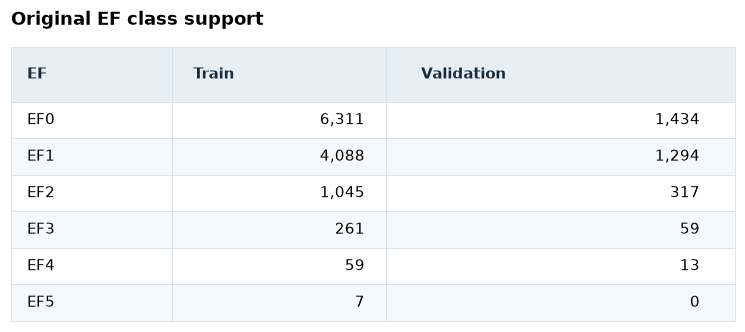

**Table 5.** Training and validation support used to define the starting classification target.

**Starting target: EF0, EF1, EF2, EF3+.** EF4 and EF5 have too little separate validation support. Combining EF3–EF5 retains 327 training and 72 validation cases; EF2 stays distinct. This is a support-based choice, not a comparison of model performance.

In [14]:
original_support = pd.DataFrame({
    split.title(): cohorts['Onset'][split][TARGET].value_counts().reindex(range(6), fill_value=0)
    for split in ['train', 'validation']
})
support_table = original_support.rename_axis('EF').reset_index()
support_table['EF'] = support_table['EF'].map(lambda rating: f'EF{rating}')
save_table(
    support_table, 'table_05_original_class_support', 'Original EF class support',
    caption='**Table 5.** Training and validation support used to define the starting classification target.',
    formats={'Train': ',d', 'Validation': ',d'}, width=7,
    results_dir=PREPARATION_DIR,
)

# Preserve EF2 as its own class; combine only the sparsest upper ratings.
TARGET_MAPPING = {0: 0, 1: 1, 2: 2, 3: 3, 4: 3, 5: 3}
CLASS_NAMES = ['EF0', 'EF1', 'EF2', 'EF3+']
N_CLASSES = len(CLASS_NAMES)
y = {
    split: cohorts['Onset'][split][TARGET].map(TARGET_MAPPING).astype('int64')
    .rename('target_class')
    for split in SPLIT_ORDER
}
assert set(y['train'].unique()) == set(range(N_CLASSES))
assert set(y['validation'].unique()) == set(range(N_CLASSES))

target_definition = {
    'source_target': TARGET, 'mapping': {str(k): v for k, v in TARGET_MAPPING.items()},
    'class_names': CLASS_NAMES, 'n_classes': N_CLASSES,
    'selection_basis': 'training and validation class support, not model or test performance',
    'rationale': 'EF5 has 7 training and 0 validation cases; EF4 has 59 and 13. '
                 'Combining EF3–EF5 gives 327 training and 72 validation cases while retaining EF2.',
    'status': 'starting four-class task; no claim of model superiority',
    'unknown_labels': 'excluded, never imputed or mapped to EF0',
    'selection_metric_for_later_models': 'validation macro-F1',
}
save_json(target_definition, DERIVED_DIR / 'target_definition.json')
for split in SPLIT_ORDER:
    pd.concat([cohorts['Onset'][split][TARGET], y[split]], axis=1).to_parquet(
        DERIVED_DIR / f'labels_{split}.parquet'
    )
display(Markdown(
    '**Starting target: EF0, EF1, EF2, EF3+.** EF4 and EF5 have too little separate validation '
    'support. Combining EF3–EF5 retains 327 training and 72 validation cases; EF2 stays distinct. '
    'This is a support-based choice, not a comparison of model performance.'
))

### Predictor sets

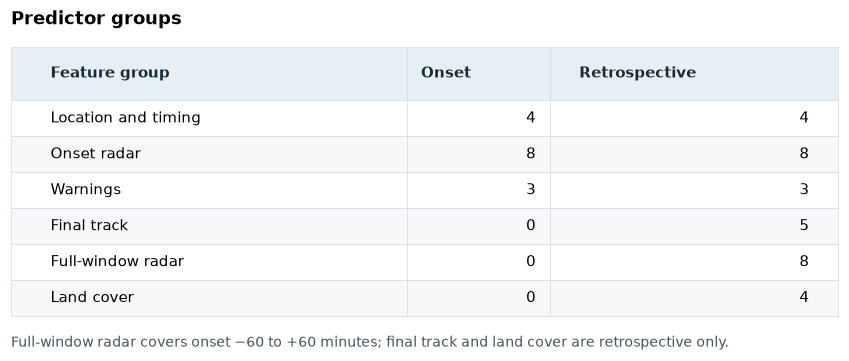

**Table 6.** Raw predictor counts by feature group before time encoding and missing-value indicators.

Month and hour use cyclic sine/cosine pairs. Nonnegative, right-skewed count, track, and impervious variables use log(1 + x). The release stores `hour_utc` as a timestamp; its encoded values were verified and converted to numeric hours in the analysis copy.

In [15]:
feature_groups = {
    'Location and timing': ['start_longitude', 'start_latitude', 'month', 'hour_utc'],
    'Onset radar': [c for c in predictors['Onset'] if c.startswith('radar_')],
    'Warnings': [c for c in predictors['Onset'] if c.startswith('warning_')],
    'Final track': ['post_end_longitude', 'post_end_latitude', 'post_path_length_miles',
                    'post_path_width_yards', 'post_duration_minutes'],
    'Full-window radar': [c for c in predictors['Retrospective'] if c.startswith('post_radar_')],
    'Land cover': [c for c in predictors['Retrospective']
                  if c.startswith('post_land_') or c == 'post_impervious_mean_percent'],
}
group_columns = [c for columns in feature_groups.values() for c in columns]
assert len(group_columns) == len(set(group_columns))
assert set(group_columns) == set(predictors['Retrospective'])

group_summary = pd.DataFrame([
    {'Feature group': group, 'Onset': len(set(columns) & set(predictors['Onset'])),
     'Retrospective': len(columns)}
    for group, columns in feature_groups.items()
])

# v2.2.1 stores hour 0–23 as epoch nanoseconds; never use datetime.dt.hour on that field.
for frame in tables.values():
    assert pd.api.types.is_datetime64_any_dtype(frame['hour_utc'])
    encoded_hour = frame['hour_utc'].astype('int64')
    assert encoded_hour.between(0, 23).all()
    np.testing.assert_array_equal(encoded_hour, frame['onset_utc'].dt.hour)
    np.testing.assert_array_equal(frame['month'], frame['onset_utc'].dt.month)

log_candidates = [
    c for c in predictors['Retrospective']
    if ('radar_' in c and c.endswith('_count'))
    or c in ['post_path_length_miles', 'post_path_width_yards',
             'post_duration_minutes', 'post_impervious_mean_percent']
]
LOG_COLUMNS = [c for c in log_candidates if training_profile.loc[c, 'skew'] > 1]
assert train[LOG_COLUMNS].min().ge(0).all()


def encode_predictors(frame, columns):
    """Apply fixed calendar and log transforms without estimating parameters."""
    encoded = frame[columns].copy()
    encoded['hour_utc'] = frame['onset_utc'].dt.hour.astype(float)
    for column, period, offset in [('month', 12, 1), ('hour_utc', 24, 0)]:
        angle = 2 * np.pi * (encoded.pop(column).astype(float) - offset) / period
        encoded[f'{column}_sin'] = np.sin(angle)
        encoded[f'{column}_cos'] = np.cos(angle)
    for column in set(LOG_COLUMNS) & set(columns):
        assert encoded[column].dropna().ge(0).all(), column
        encoded[column] = np.log1p(encoded[column])
    return encoded.astype(float)


encoded = {
    view: {split: encode_predictors(frame, predictors[view])
           for split, frame in split_frames.items()}
    for view, split_frames in cohorts.items()
}
for split in SPLIT_ORDER:
    pd.testing.assert_frame_equal(
        encoded['Onset'][split],
        encoded['Retrospective'][split][encoded['Onset'][split].columns],
    )
predictor_definition = {
    'raw_columns': predictors, 'groups': feature_groups,
    'encoded_columns': {view: frame['train'].columns.tolist() for view, frame in encoded.items()},
    'log1p_columns': LOG_COLUMNS,
    'log_selection': 'nonnegative count/track/impervious candidates with training skew > 1',
    'calendar_encoding': 'month and UTC hour replaced by sine/cosine pairs',
    'hour_correction': 'derive numeric hour from onset_utc; verified against stored epoch-nanosecond values',
    'source_files_modified': False,
}
save_json(predictor_definition, DERIVED_DIR / 'predictor_sets.json')
pd.DataFrame({'feature': LOG_COLUMNS, 'training_skew': training_profile.loc[LOG_COLUMNS, 'skew'].values}).to_csv(
    PREPARATION_DIR / 'log_transforms.csv', index=False
)
save_table(
    group_summary, 'table_06_predictor_groups', 'Predictor groups',
    caption='**Table 6.** Raw predictor counts by feature group before time encoding and missing-value indicators.',
    formats={'Onset': 'd', 'Retrospective': 'd'}, width=8,
    note='Full-window radar covers onset −60 to +60 minutes; final track and land cover are retrospective only.',
    results_dir=PREPARATION_DIR,
)
display(Markdown(
    'Month and hour use cyclic sine/cosine pairs. Nonnegative, right-skewed count, track, and '
    'impervious variables use log(1 + x). The release stores `hour_utc` as a timestamp; '
    'its encoded values were verified and converted to numeric hours in the analysis copy.'
))

### Preprocessing and class imbalance

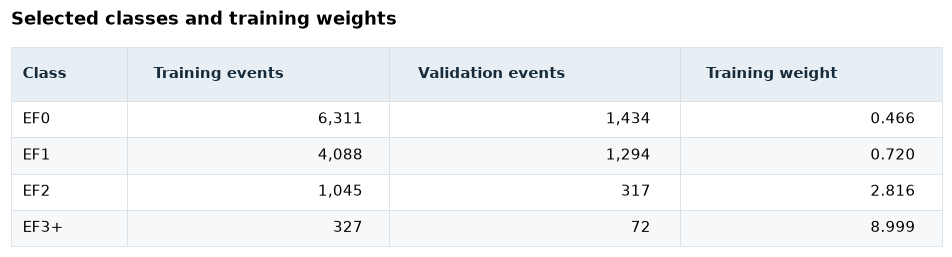

**Table 7.** Four-class support and training-only balanced weights for the planned experiments.

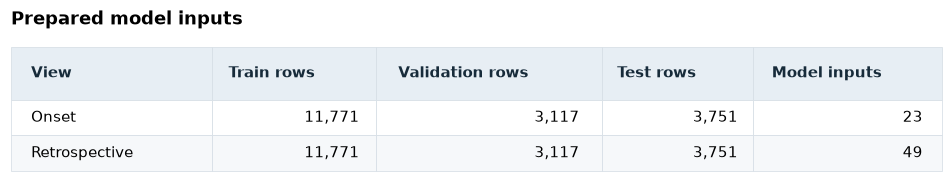

**Table 8.** Aligned inputs after time encoding, imputation, missing-value indicators, and scaling.

Missing values use training medians with indicators for fields missing in training; all resulting inputs are standardized using training statistics. Balanced training weights address class frequency without synthetic samples. These are fixed starting choices, not demonstrated performance improvements.

Section 4 complete: shared splits, four-class labels, and prepared inputs saved.
No models trained and no validation or test predictions evaluated.


In [16]:
preprocessors, X = {}, {}
preprocessing_parameters = []
for view, split_frames in encoded.items():
    train_features = split_frames['train']
    assert not train_features.isna().all().any(), 'A training predictor is entirely missing.'
    preprocessor = Pipeline([
        ('imputer', SimpleImputer(strategy='median', add_indicator=True)),
        ('scaler', StandardScaler()),
    ])
    preprocessor.fit(train_features)
    feature_names = preprocessor.get_feature_names_out().tolist()
    preprocessors[view] = preprocessor
    X[view] = {}
    for split, frame in split_frames.items():
        prepared = pd.DataFrame(
            preprocessor.transform(frame).astype('float32'),
            index=frame.index, columns=feature_names,
        )
        assert prepared.index.equals(y[split].index)
        assert np.isfinite(prepared.to_numpy()).all()
        X[view][split] = prepared
        prepared.to_parquet(DERIVED_DIR / f'{view.lower()}_{split}.parquet')

    imputer, scaler = preprocessor['imputer'], preprocessor['scaler']
    assert scaler.n_samples_seen_ == len(train_features)
    np.testing.assert_allclose(imputer.statistics_, train_features.median().to_numpy())
    np.testing.assert_allclose(X[view]['train'].mean(), 0, atol=1e-5)
    joblib.dump(preprocessor, DERIVED_DIR / f'{view.lower()}_preprocessor.joblib')
    for feature, median in zip(train_features.columns, imputer.statistics_):
        preprocessing_parameters.append({'view': view, 'feature': feature, 'training_median': float(median)})

pd.DataFrame(preprocessing_parameters).to_csv(PREPARATION_DIR / 'imputation_parameters.csv', index=False)

class_weights = dict(zip(
    range(N_CLASSES), compute_class_weight(
        class_weight='balanced', classes=np.arange(N_CLASSES), y=y['train'].to_numpy()
    ).tolist(),
))
class_summary = pd.DataFrame({
    'Class': CLASS_NAMES,
    'Training events': [int(y['train'].eq(i).sum()) for i in range(N_CLASSES)],
    'Validation events': [int(y['validation'].eq(i).sum()) for i in range(N_CLASSES)],
    'Training weight': [class_weights[i] for i in range(N_CLASSES)],
})
save_json({
    'strategy': 'balanced class weights; no resampling',
    'weights': {str(k): v for k, v in class_weights.items()},
    'formula': 'n_training / (n_classes * class_training_count)',
    'policy': 'hold weights fixed across controlled experiments; validation/test metrics unweighted',
}, DERIVED_DIR / 'class_weights.json')
save_table(
    class_summary, 'table_07_target_and_weights', 'Selected classes and training weights',
    caption='**Table 7.** Four-class support and training-only balanced weights for the planned experiments.',
    formats={'Training events': ',d', 'Validation events': ',d', 'Training weight': '.3f'},
    width=9, results_dir=PREPARATION_DIR,
)

prepared_summary = pd.DataFrame([
    {'View': view, 'Train rows': len(split_frames['train']),
     'Validation rows': len(split_frames['validation']), 'Test rows': len(split_frames['test']),
     'Model inputs': split_frames['train'].shape[1]}
    for view, split_frames in X.items()
])
save_table(
    prepared_summary, 'table_08_prepared_inputs', 'Prepared model inputs',
    caption='**Table 8.** Aligned inputs after time encoding, imputation, missing-value indicators, and scaling.',
    formats={c: ',d' for c in prepared_summary.columns[1:]}, width=9,
    results_dir=PREPARATION_DIR,
)
save_json({
    'fit_split': 'train', 'imputation': 'training median',
    'missing_indicators': 'columns with missing values in training',
    'scaling': 'training mean and standard deviation, including indicators',
    'raw_predictors': predictors, 'log1p_columns': LOG_COLUMNS,
    'input_columns': {view: split_frames['train'].columns.tolist() for view, split_frames in X.items()},
    'training_id_sha256': hashlib.sha256('\n'.join(split_ids['train']).encode()).hexdigest(),
    'sklearn_version': version('scikit-learn'),
}, DERIVED_DIR / 'preprocessing_config.json')
display(Markdown(
    'Missing values use training medians with indicators for fields missing in training; '
    'all resulting inputs are standardized using training statistics. Balanced training '
    'weights address class frequency without synthetic samples. These are fixed starting '
    'choices, not demonstrated performance improvements.'
))
print('Section 4 complete: shared splits, four-class labels, and prepared inputs saved.')
print('No models trained and no validation or test predictions evaluated.')

## 5. Neural-Network Experiments

Run controlled TensorFlow/Keras comparisons on the retrospective task, holding
preprocessing, splits, seeds, and unrelated training settings fixed.

| Experiment | Comparison |
|---|---|
| Baseline | At least three hidden ReLU Dense layers; no L1/L2 or dropout |
| SGD | Learning rates 0.1, 0.01, and 0.001 |
| L2 | Baseline versus L2 on hidden layers, starting at 0.001 |
| Dropout | Rates 0.0, 0.2, and 0.5 at fixed positions, without L2 |

Keep the optimizer and learning rate matched within L2 and dropout comparisons.
Use training/validation metrics and learning curves to assess learning speed,
overfitting, and generalization.

### Model and training helpers

### Baseline deep network

### SGD and learning rates

### L2 regularization

### Dropout

### Experiment comparison

## 6. Research Experiments

Compare retrospective feature groups, including sensitivity to final track and
damage-derived inputs, then retrain the selected approach on onset predictors.
Compare validation performance by class on the same event splits.

The onset experiment is conditional on cataloged onset and location, with an
assumed five-minute radar latency; actual real-time availability is unverified.
Final track measurements and footprint-based land cover are excluded from onset
predictors because they depend on post-event information.

### Retrospective feature groups

### Conditional onset model

### Task comparison

## 7. Final Evaluation

Evaluate the selected models using accuracy, loss, precision, recall, F1,
macro-F1, class support, and confusion matrices. Examine errors and unusual
cases to understand where each model succeeds or struggles.

### Final model choices

### Test performance

### Class-level performance

### Error analysis

## 8. Findings and Limitations

Answer the three study questions, discuss uncertainty from rare classes,
unknown labels, missingness, source linkage, and temporal transfer, and identify
next steps. Interpret feature contributions as associations; model disagreement
alone does not establish causation or an incorrect EF rating.

### Primary research findings

### Secondary experiment findings

### Training and regularization findings

### Limitations and next steps